<a href="https://www.kaggle.com/code/navneet0094/hog-ckplus?scriptVersionId=308150314" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S071_001_00000012.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S082_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S116_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S097_001_00000020.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S127_001_00000015.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000011.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S107_001_00000008.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S138_004_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S068_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S126_004_00000010.png

In [31]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [32]:
data = []
labels = []

dataset_path = "/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48"

for label, emotion in enumerate(os.listdir(dataset_path)):
    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (750, 48, 48)
Labels: [0 1 2 3 4]


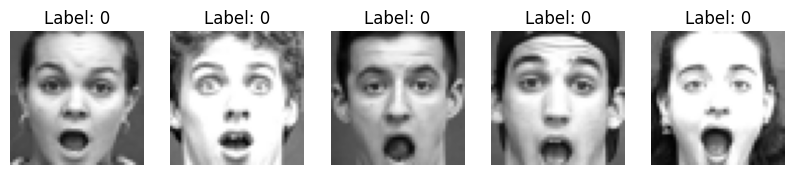

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

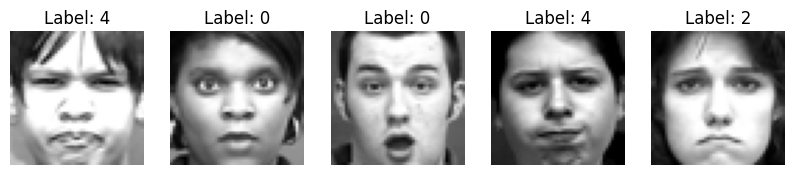

In [34]:
import random

plt.figure(figsize=(10,5))

for i in range(5):
    idx = random.randint(0, len(data)-1)
    plt.subplot(1,5,i+1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(f"Label: {labels[idx]}")
    plt.axis('off')

plt.show()

In [35]:
from skimage.feature import hog

X = []

for img in data:
    features = hog(
        img,
        orientations=9, # number of orientation bins (0 to 180)
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X.append(features)

X = np.array(X)

print("HOG feature shape:", X.shape)

HOG feature shape: (750, 900)


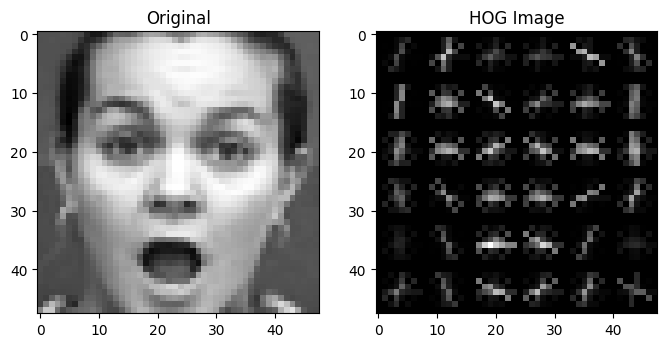

In [36]:
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [37]:
# import random
# indices = random.sample(range(len(data)), 5)
# for i in indices:
#     sample_img = data[i]
#     features, hog_image = hog(
#         sample_img,
#         orientations=9,
#         pixels_per_cell=(8,8),
#         cells_per_block=(2,2),
#         visualize=True
#     )
#     plt.figure(figsize=(6,3))

#     plt.subplot(1,2,1)
#     plt.imshow(sample_img, cmap='gray')
#     plt.title(f"Original (Label: {labels[i]})")

#     plt.subplot(1,2,2)
#     plt.imshow(hog_image, cmap='gray')
#     plt.title("HOG")

#     plt.axis('off')
#     plt.show()

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

In [39]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=1, gamma='scale')

model.fit(X_train, y_train)

SVC(C=1)

In [40]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.98


In [41]:
y_pred

array([3, 2, 0, 1, 1, 4, 2, 0, 3, 4, 0, 1, 1, 4, 0, 1, 0, 0, 2, 3, 3, 3,
       3, 1, 0, 4, 0, 2, 0, 0, 2, 3, 3, 2, 2, 0, 0, 3, 0, 3, 0, 4, 0, 0,
       4, 3, 3, 3, 2, 3, 0, 3, 2, 2, 3, 0, 3, 0, 3, 0, 4, 0, 4, 4, 1, 0,
       1, 0, 3, 4, 3, 3, 1, 3, 4, 3, 3, 0, 0, 2, 4, 0, 4, 3, 0, 2, 4, 3,
       4, 0, 3, 0, 4, 4, 0, 2, 3, 1, 0, 0, 0, 4, 0, 4, 0, 0, 4, 4, 3, 0,
       4, 3, 0, 3, 4, 4, 3, 1, 4, 0, 2, 0, 4, 1, 4, 0, 0, 3, 1, 4, 0, 0,
       0, 2, 3, 2, 0, 2, 0, 4, 2, 0, 4, 3, 0, 3, 0, 2, 4, 0])

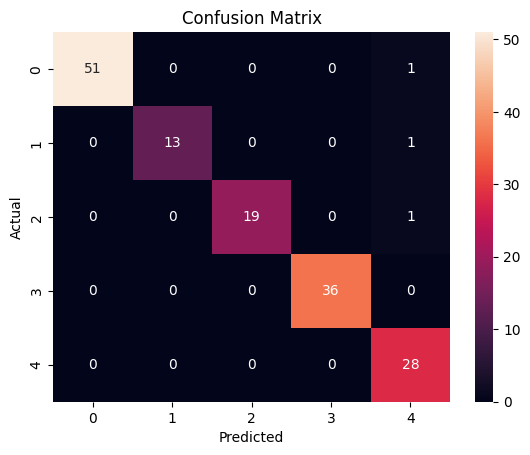

In [42]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
emotion_names = os.listdir(dataset_path)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       1.00      0.98      0.99        52
        fear       1.00      0.93      0.96        14
     sadness       1.00      0.95      0.97        20
       happy       1.00      1.00      1.00        36
       anger       0.90      1.00      0.95        28

    accuracy                           0.98       150
   macro avg       0.98      0.97      0.98       150
weighted avg       0.98      0.98      0.98       150



In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, labels, cv=5)

print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 0.9866666666666666


In [46]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv = KFold(n_splits=3, random_state=1, shuffle=True)

scores = cross_val_score(model, X, labels, scoring='accuracy', cv=cv, n_jobs=-1)

print('SVM MEAN Accuracy:', str(np.mean(scores)*100)[:5] + '%')
print('Standard deviation:', str(np.std(scores)*100)[:5] + '%')

SVM MEAN Accuracy: 96.93%
Standard deviation: 2.099%


In [47]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv = KFold(n_splits=5, random_state=1, shuffle=True)

scores = cross_val_score(model, X, labels, scoring='accuracy', cv=cv, n_jobs=-1)

print('SVM MEAN Accuracy:', str(np.mean(scores)*100)[:5] + '%')
print('Standard deviation:', str(np.std(scores)*100)[:5] + '%')

SVM MEAN Accuracy: 98.26%
Standard deviation: 1.236%


In [48]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv = KFold(n_splits=10, random_state=1, shuffle=True)

scores = cross_val_score(model, X, labels, scoring='accuracy', cv=cv, n_jobs=-1)

print('SVM MEAN Accuracy:', str(np.mean(scores)*100)[:5] + '%')
print('Standard deviation:', str(np.std(scores)*100)[:5] + '%')

SVM MEAN Accuracy: 98.66%
Standard deviation: 1.460%


In [ ]:
# import matplotlib.pyplot as plt
# emotion_names = sorted(os.listdir(dataset_path))
# plt.bar(emotion_names, counts)
# plt.xticks(rotation=45)
# plt.show()
